In [1]:
import pickle
from tqdm import tqdm
import pandas as pd
import numpy as np
import pandas as pd
from typing import Dict, List, Any
import os
import numpy as np
from collections.abc import Sequence
from typing import Dict, List, Any, Tuple

# Load raw data, and extra 13 sessions then combine

In [2]:
# def load_data(filepath):
#     with open(filepath, "rb") as f:
#         data = pickle.load(f)
#     return data

In [3]:
# data_path = "/home/aarghavan/nasShare/projects/labdul/Data_siegel/all_data_siegel_0.025.pkl"
# data = load_data(data_path)

# print(type(data))
# if isinstance(data, dict):
#     print(data.keys())
# else:
#     print(data)

In [4]:
# extra_data_path = '/home/aarghavan/nasShare/projects/labdul/Data_siegel/new_13_sessions/all_tasks/all_new_13_tasks.pkl'
# extra_data = load_data(extra_data_path)

# print(extra_data.keys())
# print(data.keys())

In [5]:
# # Check key alignment
# print("extra_data keys:", extra_data.keys())
# print("data keys:", data.keys())

# # Rename for consistency
# extra_data_renamed = extra_data.copy()

# common_keys = set(data.keys()) & set(extra_data.keys())
# print("Common keys:", common_keys)

# merged_data = {
#     'trial': data['trial'] + extra_data['trial'],  # concatenate trial lists
#     'unit': data['unit'] + extra_data['unit'],      # concatenate unit lists
#     'session': data['session'] + extra_data['session'],  # concatenate sessions
#     'spiketimes': data['spiketimes'] + extra_data_renamed['spikecounts'],
#     'trialsNeuron': data['trialsNeuron'] + extra_data['trialsNeuron'],
# }

# print(f"Original data trials: {len(data['trial'])}")
# print(f"Extra data trials: {len(extra_data['trial'])}")
# print(f"Merged data trials: {len(merged_data['trial'])}")

In [6]:
# print("extra_data keys:", merged_data.keys())
# data = merged_data

# Select Delsac task

In [7]:
# # original data 0.025 all
# # select delsac 0.025 from all 


# bin_size = 0.025
# time = np.arange(-2.5, 3.5, bin_size)   # 6.0 / 0.025 = 240 bins (no [:239])

# areas = ['PFC','FEF','LIP','Parietal','IT','MT','V4']
# wells = ['frontal', 'parietal', 'temporal']

# # keep sessions that actually contain a delsac section
# idx_sess_has_delsac = np.array(['delsac' in data["session"][i] for i in range(len(data["session"]))])

# sim_areas = []
# sim_wells = []
# correct_trials = []
# neurons_per_area = np.zeros([2, len(data["unit"]), len(areas)])
# neurons_per_well = np.zeros([2, len(data["unit"]), len(wells)])
# sim_areas = np.zeros([len(data["unit"]), len(areas)])
# sim_wells = np.zeros([len(data["unit"]), len(wells)])
# sim_trials = np.zeros(len(data["unit"]))
# data_filtered = {'trial': [], 'unit': [], 'session': [], 'spikecounts': [], 'trialsNeuron': []}

# for s_id in tqdm(np.where(idx_sess_has_delsac)[0]):
#     trial_df   = data["trial"][s_id]['allTasks']      # all trials table
#     unit_df    = data["unit"][s_id]                   # unit table
#     session_df = data["session"][s_id]['delsac']      # per-session delsac metadata
#     spikecounts = data['spiketimes'][s_id]            # (trials x timebins x units) or similar
#     trialsNeuron = data["trialsNeuron"][s_id]         # per-unit trial counts

#     # record number of correct delsac trials if present
#     if "numCorrect" in session_df:
#         sim_trials[s_id] = int(session_df["numCorrect"])

#     # ---- neuron filtering ----
#     idx_area     = np.isin(unit_df.area, areas)                  # assigned to known areas
#     idx_isolated = getattr(unit_df, "isolated", np.ones(len(unit_df), dtype=bool)).values
#     idx_min_sps  = np.array(trialsNeuron) > 100                   # activity threshold
#     filter_idx   = idx_area & idx_min_sps

#     # ---- trial filtering: keep only delsac trials ----
#     # trial_df.task may contain arrays or plain strings; handle both
#     raw_tasks = trial_df.task.values
#     if all(np.ndim(t) == 0 for t in raw_tasks):
#         # Each entry is already a scalar string
#         task_labels = np.array([str(t) for t in raw_tasks])
#     else:
#         # Each entry is an array; concatenate to flat array
#         task_labels = np.concatenate(raw_tasks)
#     delsac_idx  = (task_labels == 'delsac')

#     spikecounts_filtered = spikecounts[delsac_idx][:, filter_idx]
#     unit_df_filtered = unit_df[filter_idx]

#     data_filtered['trial'].append(data["trial"][s_id]['delsac'])
#     data_filtered['unit'].append(unit_df_filtered)
#     data_filtered['session'].append(session_df)
#     data_filtered['spikecounts'].append(spikecounts_filtered)
#     data_filtered['trialsNeuron'].append(np.array(trialsNeuron)[filter_idx])

#     # ---- counts per area / well (on filtered units) ----
#     for ai, area in enumerate(areas):
#         neurons_per_area[0, s_id, ai] = unit_df[filter_idx].query("area == @area").area.count()
#         neurons_per_area[1, s_id, ai] = unit_df[filter_idx & idx_isolated].query("area == @area").area.count()
#         if "areas" in session_df:
#             raw_areas = session_df["areas"]
#             if isinstance(raw_areas, np.ndarray) and raw_areas.ndim == 0:
#                 flat_areas = np.array([raw_areas.item()])
#             elif all(np.ndim(a) == 0 for a in np.atleast_1d(raw_areas)):
#                 flat_areas = np.atleast_1d(raw_areas)
#             else:
#                 flat_areas = np.concatenate(raw_areas)
#             sim_areas[s_id, ai] = np.sum(flat_areas == area)

#     for wi, well in enumerate(wells):
#         neurons_per_well[0, s_id, wi] = unit_df[filter_idx].query("well == @well").well.count()
#         neurons_per_well[1, s_id, wi] = unit_df[filter_idx & idx_isolated].query("well == @well").well.count()
#         if "wells" in session_df:
#             raw_wells = session_df["wells"]
#             if isinstance(raw_wells, np.ndarray) and raw_wells.ndim == 0:
#                 flat_wells = np.array([raw_wells.item()])
#             elif all(np.ndim(w) == 0 for w in np.atleast_1d(raw_wells)):
#                 flat_wells = np.atleast_1d(raw_wells)
#             else:
#                 flat_wells = np.concatenate(raw_wells)
#             sim_wells[s_id, wi] = np.sum(flat_wells == well)

# # Save + reload to check
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.025.pkl'
# with open(out_path, 'wb') as f:
#     pickle.dump(data_filtered, f)

# with open(out_path, 'rb') as f:
#     loaded_data = pickle.load(f)

# print(f"Saved filtered data to: {out_path}")


# change bin size

In [8]:
# import numpy as np
# from tqdm import tqdm
# import pickle

# bin_size = 0.025
# time = np.arange(-2.5, 3.5, bin_size)   # 240 bins

# # new coarser binning
# rebin_factor = 4
# new_bin_size = bin_size * rebin_factor   # 0.1
# new_time = np.arange(-2.5, 3.5, new_bin_size)

# areas = ['PFC','FEF','LIP','Parietal','IT','MT','V4']
# wells = ['frontal', 'parietal', 'temporal']

# idx_sess_has_delsac = np.array(['delsac' in data["session"][i] 
#                                 for i in range(len(data["session"]))])

# sim_areas = []
# sim_wells = []
# correct_trials = []
# neurons_per_area = np.zeros([2, len(data["unit"]), len(areas)])
# neurons_per_well = np.zeros([2, len(data["unit"]), len(wells)])
# sim_areas = np.zeros([len(data["unit"]), len(areas)])
# sim_wells = np.zeros([len(data["unit"]), len(wells)])
# sim_trials = np.zeros(len(data["unit"]))

# data_filtered = {'trial': [], 'unit': [], 'session': [], 
#                  'spikecounts': [], 'trialsNeuron': []}

# for s_id in tqdm(np.where(idx_sess_has_delsac)[0]):
#     trial_df   = data["trial"][s_id]['allTasks']
#     unit_df    = data["unit"][s_id]
#     session_df = data["session"][s_id]['delsac']
#     spikecounts = data['spiketimes'][s_id]  # shape: (trials, units, timebins)
#     trialsNeuron = data["trialsNeuron"][s_id]

#     # record number of correct delsac trials if present
#     if "numCorrect" in session_df:
#         sim_trials[s_id] = int(session_df["numCorrect"])

#     # ---- neuron filtering ----
#     idx_area     = np.isin(unit_df.area, areas)
#     idx_isolated = getattr(unit_df, "isolated", np.ones(len(unit_df), dtype=bool)).values
#     idx_min_sps  = np.array(trialsNeuron) > 100
#     filter_idx   = idx_area & idx_min_sps

#     # ---- trial filtering: keep only delsac trials ----
#     raw_tasks = trial_df.task.values
#     if all(np.ndim(t) == 0 for t in raw_tasks):
#         task_labels = np.array([str(t) for t in raw_tasks])
#     else:
#         task_labels = np.concatenate(raw_tasks)
#     delsac_idx  = (task_labels == 'delsac')


#     # spikecounts: (trials, units, timebins)
#     # keep only delsac trials and filtered units
#     spikecounts_filtered = spikecounts[delsac_idx][:, filter_idx, :]  # (T, U, B)

#     # ---- REBIN TIME BINS: group every 4 bins into 1 ----
#     n_bins = spikecounts_filtered.shape[-1]
#     trim_len = (n_bins // rebin_factor) * rebin_factor  # should be 240 → 240
#     spikecounts_trimmed = spikecounts_filtered[..., :trim_len]

#     # reshape and sum last dimension in groups of 4
#     T, U, B = spikecounts_trimmed.shape
#     spikecounts_rebinned = (
#         spikecounts_trimmed
#         .reshape(T, U, B // rebin_factor, rebin_factor)
#         .sum(axis=-1)
#     )  # shape: (T, U, 60) for 0.1 s bins

#     unit_df_filtered = unit_df[filter_idx]

#     data_filtered['trial'].append(data["trial"][s_id]['delsac'])
#     data_filtered['unit'].append(unit_df_filtered)
#     data_filtered['session'].append(session_df)
#     data_filtered['spikecounts'].append(spikecounts_rebinned)
#     data_filtered['trialsNeuron'].append(np.array(trialsNeuron)[filter_idx])

#     # ---- counts per area / well (on filtered units) ----
#     for ai, area in enumerate(areas):
#         neurons_per_area[0, s_id, ai] = unit_df[filter_idx].query("area == @area").area.count()
#         neurons_per_area[1, s_id, ai] = unit_df[filter_idx & idx_isolated].query("area == @area").area.count()
#         if "areas" in session_df:
#             raw_areas = session_df["areas"]
#             if isinstance(raw_areas, np.ndarray) and raw_areas.ndim == 0:
#                 flat_areas = np.array([raw_areas.item()])
#             elif all(np.ndim(a) == 0 for a in np.atleast_1d(raw_areas)):
#                 flat_areas = np.atleast_1d(raw_areas)
#             else:
#                 flat_areas = np.concatenate(raw_areas)
#             sim_areas[s_id, ai] = np.sum(flat_areas == area)

#     for wi, well in enumerate(wells):
#         neurons_per_well[0, s_id, wi] = unit_df[filter_idx].query("well == @well").well.count()
#         neurons_per_well[1, s_id, wi] = unit_df[filter_idx & idx_isolated].query("well == @well").well.count()
#         if "wells" in session_df:
#             raw_wells = session_df["wells"]
#             if isinstance(raw_wells, np.ndarray) and raw_wells.ndim == 0:
#                 flat_wells = np.array([raw_wells.item()])
#             elif all(np.ndim(w) == 0 for w in np.atleast_1d(raw_wells)):
#                 flat_wells = np.atleast_1d(raw_wells)
#             else:
#                 flat_wells = np.concatenate(raw_wells)
#             sim_wells[s_id, wi] = np.sum(flat_wells == well)

# # Save + reload to check
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1.pkl'
# with open(out_path, 'wb') as f:
#     pickle.dump(data_filtered, f)

# with open(out_path, 'rb') as f:
#     loaded_data = pickle.load(f)

# print(f"Saved filtered data to: {out_path}")
# print("Example rebinned shape (session 0):", loaded_data['spikecounts'][0].shape if len(loaded_data['spikecounts']) > 0 else None)


In [9]:
# delsac binned 0.1 available

with open('/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1.pkl', 'rb') as f:
    delsac_data = pickle.load(f)

In [10]:
# with open('/home/aarghavan/aslan/data/response_all.pkl', 'rb') as f:
#     response_all = pickle.load(f)

# response_all[['targX',
#        'targY', 'respEcc_raw', 'respAng_raw', 'respX_dva', 'respY_dva',
#        'respEcc_dva', 'respAng_dva']]

In [11]:
# # add targetX and targetY to each session's trial delsac_data

# for sess in range(len(delsac_data['trial'])):
#     df = delsac_data['trial'][sess]
#     pos = df['targetPos']

#     # --- standardize pos to (nTrials,2) array of floats ---
#     if isinstance(pos, np.ndarray) and pos.ndim == 2 and pos.shape[1] >= 2:
#         arr = pos
#     else:
#         arr = np.vstack(pd.Series(pos).to_numpy())

#     ecc   = arr[:,0]
#     theta = arr[:,1]                          # deg

#     theta_rad = np.deg2rad(theta)             # convert to rad

#     x = ecc * np.cos(theta_rad)
#     y = ecc * np.sin(theta_rad)

#     df.loc[:, 'targetX'] = x
#     df.loc[:, 'targetY'] = y

In [12]:
# import numpy as np
# import pandas as pd

# def to_scalar_session(x):
#     if isinstance(x, (list, tuple, np.ndarray)) and len(x) > 0:
#         x = x[0]
#     return x

# def norm_key_session(x):
#     x = to_scalar_session(x)
#     try:
#         return str(int(x))
#     except Exception:
#         return str(x).strip()

# def norm_key_trial(x):
#     try:
#         return str(int(x))
#     except Exception:
#         return str(x).strip()

# # Prepare keys in response_all once
# response_all = response_all.copy()
# response_all['session_key'] = response_all['session_id'].apply(norm_key_session)
# response_all['trial_key']   = response_all['trial_id'].apply(norm_key_trial)

# for sess in range(len(delsac_data['trial'])):
#     df = delsac_data['trial'][sess].copy()

#     # Normalize join keys
#     df['session_key'] = df['session'].apply(norm_key_session)
#     df['trial_key']   = df['trial'].apply(norm_key_trial)

#     # Reset index to avoid alignment by weird labels
#     df = df.reset_index(drop=True)

#     merged = df.merge(
#         response_all[['session_key','trial_key','respX_dva','respY_dva']],
#         on=['session_key','trial_key'],
#         how='left',
#         validate='m:1'
#     )

#     # Assign by position (avoid index alignment)
#     df['respX_dva'] = merged['respX_dva'].to_numpy()
#     df['respY_dva'] = merged['respY_dva'].to_numpy()

#     # (optional) drop helper keys
#     df = df.drop(columns=['session_key','trial_key'])

#     # write back
#     delsac_data['trial'][sess] = df


In [13]:
# delsac_data['trial'][0].columns

In [14]:

# for i in range(len(delsac_data['trial'])):
#     delsac_data['trial'][i].rename(
#         columns={'respX_dva': 'respX', 'respY_dva': 'respY'},
#         inplace=True
#     )

In [15]:
# for sess in range(len(delsac_data['trial'])):
#     df = delsac_data['trial'][sess]
#     df['targetAng'] = np.degrees(np.arctan2(df['targetY'], df['targetX']))
#     df['respAng']   = np.degrees(np.arctan2(df['respY'], df['respX']))

In [16]:
# delsac_data['trial'][4][(delsac_data['trial'][0]['correct'] == 1)][['correct','targetX', 'targetY', 'respX', 'respY', 'targetAng', 'respAng']]


# remove NaN

In [17]:
# import pickle
# import numpy as np
# import pandas as pd

# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1_noNaN.pkl'


# # columns to clean (support both naming variants for response)
# def response_cols(df):
#     if {'respX_dva','respY_dva'}.issubset(df.columns):
#         return ['respX_dva', 'respY_dva']
#     elif {'respX','respY'}.issubset(df.columns):
#         return ['respX', 'respY']
#     else:
#         return None

# n_sessions = len(delsac_data['trial'])
# dropped_total = 0

# for i in range(n_sessions):
#     df = delsac_data['trial'][i]
#     spikes = delsac_data['spikecounts'][i]  # expected shape: (trials, timebins, units) or (trials, ...)

#     # Figure out which response columns exist in this session
#     resp_cols = response_cols(df)
#     if resp_cols is None:
#         print(f"Session {i}: skipping (no response columns found)")
#         continue

#     cols = ['targetX', 'targetY'] + resp_cols
#     missing = [c for c in cols if c not in df.columns]
#     if missing:
#         print(f"Session {i}: skipping (missing columns: {missing})")
#         continue

#     # Build a finite (not NaN/inf) mask across the selected columns
#     vals = df[cols].to_numpy(dtype=float)
#     keep_mask = np.isfinite(vals).all(axis=1)  # True if all finite in those cols

#     # Sanity check: trials dimension must match
#     n_trials_df = len(df)
#     n_trials_spk = spikes.shape[0]
#     if n_trials_df != n_trials_spk:
#         raise ValueError(
#             f"Session {i}: trial count mismatch between trial DF ({n_trials_df}) "
#             f"and spikecounts ({n_trials_spk})."
#         )

#     dropped = (~keep_mask).sum()
#     dropped_total += dropped

#     if dropped > 0:
#         df = df.loc[keep_mask].reset_index(drop=True)
#         # Slice neural data on the trial axis
#         spikes = spikes[keep_mask]

#         delsac_data['trial'][i] = df
#         delsac_data['spikecounts'][i] = spikes

#         # Note: we leave unit/session/trialsNeuron unchanged (trial removal doesn't change unit metadata).
#         print(f"Session {i}: dropped {dropped} trial(s) with NaN/inf in {cols}. "
#               f"Remaining trials: {len(df)}")
#     else:
#         print(f"Session {i}: no NaNs/inf in {cols} — nothing dropped.")

# print(f"Total dropped across sessions: {dropped_total}")

# # Save cleaned data
# with open(out_path, 'wb') as f:
#     pickle.dump(delsac_data, f)
# print(f"Saved cleaned data to: {out_path}")


In [18]:
# import numpy as np
# from tqdm import tqdm
# import pickle

# bin_size = 0.025
# time = np.arange(-2.5, 3.5, bin_size)   # 240 bins

# # new coarser binning
# rebin_factor = 4
# new_bin_size = bin_size * rebin_factor   # 0.1
# new_time = np.arange(-2.5, 3.5, new_bin_size)

# areas = ['PFC','FEF','LIP','Parietal','IT','MT','V4']
# wells = ['frontal', 'parietal', 'temporal']

# idx_sess_has_delsac = np.array(['delsac' in data["session"][i] 
#                                 for i in range(len(data["session"]))])

# sim_areas = []
# sim_wells = []
# correct_trials = []
# neurons_per_area = np.zeros([2, len(data["unit"]), len(areas)])
# neurons_per_well = np.zeros([2, len(data["unit"]), len(wells)])
# sim_areas = np.zeros([len(data["unit"]), len(areas)])
# sim_wells = np.zeros([len(data["unit"]), len(wells)])
# sim_trials = np.zeros(len(data["unit"]))

# data_filtered = {'trial': [], 'unit': [], 'session': [], 
#                  'spikecounts': [], 'trialsNeuron': []}

# for s_id in tqdm(np.where(idx_sess_has_delsac)[0]):
#     trial_df   = data["trial"][s_id]['allTasks']
#     unit_df    = data["unit"][s_id]
#     session_df = data["session"][s_id]['delsac']
#     spikecounts = data['spiketimes'][s_id]  # shape: (trials, units, timebins)
#     trialsNeuron = data["trialsNeuron"][s_id]

#     # record number of correct delsac trials if present
#     if "numCorrect" in session_df:
#         sim_trials[s_id] = int(session_df["numCorrect"])

#     # ---- neuron filtering ----
#     idx_area     = np.isin(unit_df.area, areas)
#     idx_isolated = getattr(unit_df, "isolated", np.ones(len(unit_df), dtype=bool)).values
#     idx_min_sps  = np.array(trialsNeuron) > 100
#     filter_idx   = idx_area & idx_min_sps

#     # ---- trial filtering: keep only delsac trials ----
#     task_labels = np.concatenate(trial_df.task.values)
#     delsac_idx  = (task_labels == 'delsac')

#     # spikecounts: (trials, units, timebins)
#     # keep only delsac trials and filtered units
#     spikecounts_filtered = spikecounts[delsac_idx][:, filter_idx, :]  # (T, U, B)

#     # ---- REBIN TIME BINS: group every 4 bins into 1 ----
#     n_bins = spikecounts_filtered.shape[-1]
#     trim_len = (n_bins // rebin_factor) * rebin_factor  # should be 240 → 240
#     spikecounts_trimmed = spikecounts_filtered[..., :trim_len]

#     # reshape and sum last dimension in groups of 4
#     T, U, B = spikecounts_trimmed.shape
#     spikecounts_rebinned = (
#         spikecounts_trimmed
#         .reshape(T, U, B // rebin_factor, rebin_factor)
#         .sum(axis=-1)
#     )  # shape: (T, U, 60) for 0.1 s bins

#     unit_df_filtered = unit_df[filter_idx]

#     data_filtered['trial'].append(data["trial"][s_id]['delsac'])
#     data_filtered['unit'].append(unit_df_filtered)
#     data_filtered['session'].append(session_df)
#     data_filtered['spikecounts'].append(spikecounts_rebinned)
#     data_filtered['trialsNeuron'].append(np.array(trialsNeuron)[filter_idx])

#     # ---- counts per area / well (on filtered units) ----
#     for ai, area in enumerate(areas):
#         neurons_per_area[0, s_id, ai] = unit_df[filter_idx].query("area == @area").area.count()
#         neurons_per_area[1, s_id, ai] = unit_df[filter_idx & idx_isolated].query("area == @area").area.count()
#         if "areas" in session_df:
#             sim_areas[s_id, ai] = np.sum(np.concatenate(session_df["areas"]) == area)

#     for wi, well in enumerate(wells):
#         neurons_per_well[0, s_id, wi] = unit_df[filter_idx].query("well == @well").well.count()
#         neurons_per_well[1, s_id, wi] = unit_df[filter_idx & idx_isolated].query("well == @well").well.count()
#         if "wells" in session_df:
#             sim_wells[s_id, wi] = np.sum(np.concatenate(session_df["wells"]) == well)

# # Save + reload to check
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_filtered_bin_0.1.pkl'
# with open(out_path, 'wb') as f:
#     pickle.dump(data_filtered, f)

# with open(out_path, 'rb') as f:
#     loaded_data = pickle.load(f)

# print(f"Saved filtered data to: {out_path}")
# print("Example rebinned shape (session 0):", loaded_data['spikecounts'][0].shape if len(loaded_data['spikecounts']) > 0 else None)


In [19]:
# delsac_data['spikecounts'][0][0][0].shape

In [2]:
with open('/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1_noNaN_aligned.pkl', 'rb') as f: ## change it for your data
    data = pickle.load(f)

In [21]:
data['spikecounts'][0].shape
data.keys()

data['trial'][0].columns

Index(['trial', 'taskTrial', 'bhvTrial', 'condition', 'task', 'outcome',
       'correct', 'reactionTime', 'numRewards', 'mapColors', 'mapDirections',
       'targetPos', 'trialStart', 'fixptOn', 'fixationTime', 'fixptOn2',
       'stimOn', 'stimOff', 'targetOn', 'targetOff', 'fixptOff',
       'responseTime', 'responseDone', 'holdTgtOn', 'holdTgtOff',
       'responseHeld', 'outcomeTime', 'rewardOn', 'rewardOff', 'feedbackOff',
       'trialEnd', 'session', 'trialRefTimes', 'badTimingTrials', 'badTrials',
       'targetX', 'targetY', 'respX', 'respY', 'targetXY', 'respXY',
       'targetAng', 'respAng'],
      dtype='object')

In [22]:
# data['trial'][0]['session']
data['trial'][0][['mapColors', 'mapDirections']]
data['trial'][15][['mapColors', 'mapDirections']]

,mapColors,mapDirections
0,"(0, 90, -90, 90, -135, -90, -45, 90)","(-135, 90, 135, -180, 45, -90, -45, -135)"
1,"(-45, -180, 0, 90, 0, -180, 45, -45)","(45, 45, -90, -180, 45, -45, 0, -180)"
2,"(-90, -180, -135, -180, -180, -135, 0, -135)","(-90, -135, -45, 90, 45, -90, 135, 90)"
3,"(0, -90, 135, 90, 135, -90, 135, 90)","(-90, 135, 45, 0, -45, -135, -135, -135)"
4,"(-180, 135, 90, 45, 135, 45, -90, 0)","(-135, -180, 45, -90, 135, -135, -135, -45)"
...,...,...
69,"(135, -180, -90, 90, 0, -135, -180, -45)","(135, 135, -180, 45, -135, 90, 45, 0)"
70,"(0, 135, -135, 90, 45, -180, -180, -180)","(45, -180, 0, 135, -45, -45, 0, 135)"
71,"(0, 90, -135, 90, 45, -45, 45, 45)","(-45, -90, -135, 135, -180, -135, 0, -135)"
72,"(-90, -180, 0, 0, -90, -90, -90, 0)","(135, -180, -135, -45, 90, -180, -45, 90)"


In [23]:
# select these sessions 'nMapStim' == 6

# ['100706', '100724', '100725', '100726', '100730', '100731', '100802', '100803', '100804', '100817', '100818', 
#  '100819', '100820', '100823', '100824', '100826', '100827', '100828', '101122', '101123', '101124', '101127', 
#  '101128', '101202', '101206', '101207', '101209', '101210', '101216', '100907', '100910', '100913', '100915', 
#  '100917', '100920', '100921', '101008', '101009', '101023', '101024', '101027', '101028', '101030', '110120', 
#  '110121']



# # (nMapStim == 6) | (nMapStim == 8) --> 52 sessions
# v72_sessions = [
#     '100706', '100819', '100917', '101123', '110107_02',
#     '100724', '100820', '100920', '101124', '110110_01', 
#     '100725', '100823', '100921', '101127', '110110_02', '110120',
#     '100726', '100824', '101008', '101128', '110111_01', '110121',
#     '100730', '100826', '101009', '101202', '110111_02',
#     '100731', '100827', '101023', '101206',  
#     '100802', '100828', '101024', '101207', 
#     '100803', '100907', '101027', '101209', '110115_01',
#     '100804', '100910', '101028', '101210',
#     '100817', '100913', '101030', '101216', 
#     '100818', '100915', '101122', '110107_01',
# ]



# (nMapStim == 6) --> 45 sessions
# v72_sessions = [
#     '100706', '100819', '100917', '101123',
#     '100724', '100820', '100920', '101124', 
#     '100725', '100823', '100921', '101127', '110120',
#     '100726', '100824', '101008', '101128', '110121',
#     '100730', '100826', '101009', '101202',
#     '100731', '100827', '101023', '101206',  
#     '100802', '100828', '101024', '101207', 
#     '100803', '100907', '101027', '101209',
#     '100804', '100910', '101028', '101210',
#     '100817', '100913', '101030', '101216', 
#     '100818', '100915', '101122',
# ]

# # extra_sessions --> 13 sessions, error in loading '110214', '110215'
# v73_sessions = [
#     '110112_01', '110112_02', '110115_02', '110116_01',
#     '110116_02', '110117_01', '110117_02','110214',
#     '110215', '110216', '110218', '110219', '110220']





# Filter based on ITI (consecutive trials, important for memory reactivations)

In [24]:
# import numpy as np
# import pandas as pd

# MAX_ITI_DURATION = 5.0  # seconds, change if needed

# def recompute_trialsNeuron_from_spikecounts(spikecounts_filtered):
#     """
#     Derive a per-unit trial-count array from spikecounts after trial-filtering.
#     Heuristic:
#       - If spikecounts_filtered is 3D (trials x timebins x units): count trials where any spike across timebins for each unit.
#       - If 2D (trials x units): count nonzero entries per unit across trials.
#       - If shape ambiguous, return None.
#     """
#     if spikecounts_filtered is None:
#         return None
#     sc = np.asarray(spikecounts_filtered)
#     if sc.size == 0:
#         # zero trials -> zero counts (return empty array matching unit axis if possible)
#         # best-effort: if we can guess units from original shape, return zeros
#         return np.array([])
#     if sc.ndim == 3:
#         # assume trials x timebins x units
#         # count trials having any nonzero across timebins for each unit
#         return np.sum(np.any(sc != 0, axis=1), axis=0)
#     elif sc.ndim == 2:
#         # assume trials x units
#         return np.sum(sc != 0, axis=0)
#     else:
#         # fallback: try to collapse trailing axes, treat last axis as units
#         try:
#             # move trial axis (0) and last axis as unit
#             # count any nonzero across axes 1..n-1 for each trial and then per unit
#             sc_trial_unit = sc  # best-effort; may fail
#             # reshape to (trials, -1, units) not possible generically; so return None
#             return None
#         except Exception:
#             return None

# def filter_data_filtered_by_iti(data_filtered, max_iti=MAX_ITI_DURATION):
#     """
#     Input:
#       data_filtered: dict with keys like 'trial','unit','session','spikecounts','trialsNeuron'
#                      where each value is a list aligned across sessions.
#     Output:
#       new_data_filtered: same structure but only sessions with >=1 kept trial and all keys
#                          trimmed so removed trials are also removed from spikecounts/trialsNeuron.
#     """
#     # init output structure with same keys
#     new_data_filtered = {k: [] for k in data_filtered.keys()}

#     n_sessions = len(data_filtered['trial'])
#     for s in range(n_sessions):
#         trial_df = data_filtered['trial'][s].copy()  # DataFrame of trials for this session

#         # make sure required columns exist; if not, skip session with warning
#         # (we'll try to be robust: use .get to avoid KeyError)
#         # coerce to numeric where possible
#         trial_df['responseDone'] = pd.to_numeric(trial_df.get('responseDone'), errors='coerce')
#         trial_df['trialRefTimes'] = pd.to_numeric(trial_df.get('trialRefTimes'), errors='coerce')
#         trial_df['fixptOn'] = pd.to_numeric(trial_df.get('fixptOn'), errors='coerce')

#         # compute trial ends / starts
#         trial_df['trial_ends'] = trial_df['responseDone'] + trial_df['trialRefTimes']
#         trial_df['trial_starts'] = trial_df['fixptOn'] + trial_df['trialRefTimes']

#         # ITI = next start - this end
#         trial_df['ITI'] = trial_df['trial_starts'].shift(-1) - trial_df['trial_ends']

#         # coerce ITI numeric
#         trial_df['ITI'] = pd.to_numeric(trial_df['ITI'], errors='coerce')

#         # keep mask: valid ITI and less-equal threshold
#         keep_mask = trial_df['ITI'].notna() & (trial_df['ITI'] <= max_iti)

#         # If you want to KEEP also the last trial when ITI is NaN, you could modify logic.
#         # As requested, we remove trials without acceptable ITI (so last trial is usually removed).
#         n_kept = keep_mask.sum()
#         if n_kept == 0:
#             # skip this session entirely (no surviving trials)
#             # optional: print a message
#             # print(f"Session {s}: 0 trials pass ITI <= {max_iti}. Skipping session.")
#             continue

#         # Filter trial DataFrame and reset index
#         trial_df_filtered = trial_df.loc[keep_mask].reset_index(drop=True)

#         # Now filter spikecounts (if present)
#         spikecounts_filtered = None
#         if 'spikecounts' in data_filtered and len(data_filtered['spikecounts']) > s:
#             sc = data_filtered['spikecounts'][s]
#             # Convert to numpy array if possible (but preserve if it's a list)
#             try:
#                 sc_arr = np.asarray(sc)
#             except Exception:
#                 sc_arr = None

#             if isinstance(sc, list):
#                 # if sc is a list of per-trial items, apply list mask
#                 # keep order of trials where keep_mask True
#                 mask_bool = keep_mask.values.astype(bool)
#                 spikecounts_filtered = [sc[i] for i, keep in enumerate(mask_bool) if keep]
#                 # optionally convert to np.array if homogeneous
#                 try:
#                     spikecounts_filtered = np.asarray(spikecounts_filtered)
#                 except Exception:
#                     pass
#             elif sc_arr is not None and sc_arr.size > 0:
#                 # assume trial axis is axis 0
#                 # Ensure mask length matches trials dim
#                 if sc_arr.shape[0] != len(keep_mask):
#                     # shape mismatch: try to warn and skip spikecounts update
#                     # print(f"Warning: spikecounts trials dim {sc_arr.shape[0]} != trial_df {len(keep_mask)} for session {s}; skipping spikecounts filtering.")
#                     spikecounts_filtered = None
#                 else:
#                     # apply mask on axis 0
#                     spikecounts_filtered = sc_arr[keep_mask.values, ...]
#             else:
#                 spikecounts_filtered = None

#         # Update trialsNeuron if present
#         trialsNeuron_filtered = None
#         if 'trialsNeuron' in data_filtered and len(data_filtered['trialsNeuron']) > s:
#             tn = data_filtered['trialsNeuron'][s]
#             # prefer to recompute from spikecounts_filtered if available
#             if spikecounts_filtered is not None:
#                 recomputed = recompute_trialsNeuron_from_spikecounts(spikecounts_filtered)
#                 if recomputed is not None and recomputed.size > 0:
#                     trialsNeuron_filtered = recomputed
#                 else:
#                     # fallback: filter existing trialsNeuron if it is aligned to trials (unlikely)
#                     # If trialsNeuron was per-unit counts, we keep it but warn it's unchanged
#                     # print(f"Note: recomputed trialsNeuron was not available for session {s}, keeping original.")
#                     trialsNeuron_filtered = tn
#             else:
#                 # cannot recompute; keep original (or set None)
#                 trialsNeuron_filtered = tn

#         # Append filtered session to new_data_filtered, keeping unit and session metadata the same
#         new_data_filtered['trial'].append(trial_df_filtered)
#         # keep unit (units were already filtered in first-level pass)
#         if 'unit' in data_filtered and len(data_filtered['unit']) > s:
#             new_data_filtered['unit'].append(data_filtered['unit'][s])
#         if 'session' in data_filtered and len(data_filtered['session']) > s:
#             new_data_filtered['session'].append(data_filtered['session'][s])
#         if 'spikecounts' in data_filtered:
#             new_data_filtered['spikecounts'].append(spikecounts_filtered)
#         if 'trialsNeuron' in data_filtered:
#             new_data_filtered['trialsNeuron'].append(trialsNeuron_filtered)

#         # copy over any other keys unchanged (safe-guard)
#         for k in data_filtered.keys():
#             if k in ('trial','unit','session','spikecounts','trialsNeuron'):
#                 continue
#             # append original element if exists
#             if len(data_filtered[k]) > s:
#                 new_data_filtered[k].append(data_filtered[k][s])

#     return new_data_filtered

# # Usage:
# data_filtered_iti = filter_data_filtered_by_iti(filtered_data, max_iti=MAX_ITI_DURATION)

# # Quick summary:
# print(f"Original sessions: {len(filtered_data['trial'])}")
# print(f"Surviving sessions after ITI filter: {len(data_filtered_iti['trial'])}")


In [25]:
data['trial'][1]['session']

0      [100731]
1      [100731]
2      [100731]
3      [100731]
4      [100731]
         ...   
137    [100731]
138    [100731]
139    [100731]
140    [100731]
141    [100731]
Name: session, Length: 142, dtype: object

In [26]:
data['spikecounts'][1].shape   

(142, 129, 59)

In [27]:
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_filtered_6_nMapStim.pkl'
# with open(out_path, 'wb') as f:
#     pickle.dump(data_filtered_iti, f)

In [3]:

def _angle_deg(x, y):
    """
    Return angle in degrees wrapped to (-180, 180].
    Works with scalars or numpy arrays.
    """
    ang = np.degrees(np.arctan2(y, x))
    return (ang + 180.0) % 360.0 - 180.0


def add_response_metrics(df_trials: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Dict[str, np.ndarray]]]:
    """
    Per session:
      - Fit a 2x2 map A on correct trials in baseline-relative space (no intercept).
      - Compute response metrics in raw baseline-relative coords (respEcc/respAng).
      - Transform responses to dva via Ainv, and compute respX/Y_dva + respEcc/Ang_dva.

    Parameters
    ----------
    df_trials : DataFrame
        Must contain columns:
        ['session_id','correct','targX','targY','endX_raw','endY_raw','fixBaseX_raw','fixBaseY_raw']

    Returns
    -------
    df_out : DataFrame
        Copy of input with added columns:
        ['respEcc_raw','respAng_raw','respX_dva','respY_dva','respEcc_dva','respAng_dva']
    per_session_fit : dict
        Mapping session_id -> {'A': 2x2 ndarray or None, 'Ainv': 2x2 ndarray or None}
    """
    df = df_trials.copy().reset_index(drop=True)
    if "session_id" in df.columns:
        df["session_id"] = df["session_id"].astype(str)

    out_cols = ["respEcc_raw","respAng_raw","respX_dva","respY_dva","respEcc_dva","respAng_dva"]
    for col in out_cols:
        df[col] = np.nan

    per_session_fit: Dict[str, Dict[str, np.ndarray]] = {}

    needed = ["correct","targX","targY","endX_raw","endY_raw","fixBaseX_raw","fixBaseY_raw"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"add_response_metrics_big: missing required columns: {missing}")

    # Group by session and process
    for sid, rows in df.groupby("session_id", sort=False):
        idx = rows.index

        good = (rows["correct"] == 1) & rows[needed].notna().all(axis=1)

        R_all = rows[["endX_raw","endY_raw"]].to_numpy(float)
        B_all = rows[["fixBaseX_raw","fixBaseY_raw"]].to_numpy(float)
        R_all_rel = R_all - B_all

        # Raw (baseline-relative) response metrics
        respEcc_raw = np.hypot(R_all_rel[:, 0], R_all_rel[:, 1])
        respAng_raw = _angle_deg(R_all_rel[:, 0], R_all_rel[:, 1])

        # Defaults for dva
        respX_dva = np.full(len(rows), np.nan, float)
        respY_dva = np.full(len(rows), np.nan, float)

        A = None
        Ainv = None

        if np.any(good):
            T = rows.loc[good, ["targX","targY"]].to_numpy(float)               # (N x 2)
            R = rows.loc[good, ["endX_raw","endY_raw"]].to_numpy(float)         # (N x 2)
            B = rows.loc[good, ["fixBaseX_raw","fixBaseY_raw"]].to_numpy(float) # (N x 2)
            R_rel = R - B

            A, *_ = np.linalg.lstsq(T, R_rel, rcond=None)  # (2x2)
            Ainv = np.linalg.pinv(A)

            # Transform all responses into dva coords
            respXY_dva = R_all_rel @ Ainv
            respX_dva[:] = respXY_dva[:, 0]
            respY_dva[:] = respXY_dva[:, 1]

        # Write back to main df
        df.loc[idx, "respEcc_raw"] = respEcc_raw
        df.loc[idx, "respAng_raw"] = respAng_raw
        df.loc[idx, "respX_dva"]   = respX_dva
        df.loc[idx, "respY_dva"]   = respY_dva
        df.loc[idx, "respEcc_dva"] = np.hypot(respX_dva, respY_dva)
        df.loc[idx, "respAng_dva"] = _angle_deg(respX_dva, respY_dva)

        per_session_fit[str(sid)] = {"A": A, "Ainv": Ainv}

    return df, per_session_fit



def circ_diff(a: float, b: float) -> float:
    """Circular difference (a - b) wrapped to [-180, 180]."""
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return (a - b + 180) % 360 - 180


def circ_err(curr: float, resp: float) -> float:
    """Circular error (curr - resp) wrapped to [-180, 180]."""
    if pd.isna(curr) or pd.isna(resp):
        return np.nan
    return (curr - resp + 180) % 360 - 180


def add_memory_delay_features(merged: pd.DataFrame) -> pd.DataFrame:
    """
    Add memory-delay and circular metrics:
      - memoryDelay  = responseTime - fixptOff
      - prev         = previous trial's target angle
      - diff         = |circular(prev - curr)|  (change in target direction)
      - err          = circular(curr - resp)   (angular response error)

    Parameters
    ----------
    merged : pd.DataFrame
        Must include columns:
        ['responseTime','fixptOff','targAng','respAng_dva']

    Returns
    -------
    df : pd.DataFrame
        Copy of merged with added columns:
        ['memoryDelay','prev','diff','err']
    """
    df = merged.copy()

    required = ["responseTime", "fixptOff", "targAng", "respAng_dva"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for add_memory_delay_features: {missing}")

    # Memory delay (in same time units as input)
    df["memoryDelay"] = df["responseTime"] - df["fixptOff"]

    # Current, previous, and response angles
    df["curr"] = df["targAng"]
    df["resp"] = df["respAng_dva"]
    df["prev"] = df["curr"].shift(1)

    # Vectorized circular ops
    curr = df["curr"].to_numpy()
    prev = df["prev"].to_numpy()
    resp = df["resp"].to_numpy()

    # signed target-to-target distance: θ_d = curr - prev (wrapped)
    diff_signed = (curr - prev + 180) % 360 - 180
    diff_signed[np.isnan(prev)] = np.nan 

    # error: θ_e = curr - resp (wrapped)
    err = (curr - resp + 180) % 360 - 180

    # store
    df["diff_signed"] = diff_signed
    df["diff_abs"] = np.abs(diff_signed)
    df["err"] = err
    df["folded_err"] = df["err"] * np.where(df["diff_signed"] >= 0, 1, -1)

    # (optional) keep backward-compatibility: `diff` column as absolute
    df["diff"] = df["diff_abs"]

    return df

In [4]:
# Example: compute angular features per session using data you already have
for sess in range(len(data['trial'])):
    df = data['trial'][sess].copy()
    
    # Compute target and response angles (if not already present)
    if 'targetAng' not in df.columns:
        df['targetAng'] = np.degrees(np.arctan2(df['targetY'], df['targetX']))
    if 'respAng' not in df.columns:
        df['respAng'] = np.degrees(np.arctan2(df['respY'], df['respX']))
    
    # Memory delay
    if 'fixptOff' in df.columns and 'responseTime' in df.columns:
        df['memoryDelay'] = pd.to_numeric(df['responseTime'], errors='coerce') - \
                            pd.to_numeric(df['fixptOff'], errors='coerce')
    
    # Previous target angle
    df['prev_targetAng'] = df['targetAng'].shift(1)
    
    # Signed circular difference (curr - prev), wrapped to [-180, 180]
    curr = df['targetAng'].to_numpy()
    prev = df['prev_targetAng'].to_numpy()
    resp = df['respAng'].to_numpy()
    
    diff_signed = (curr - prev + 180) % 360 - 180
    diff_signed[np.isnan(prev)] = np.nan
    
    err = (curr - resp + 180) % 360 - 180
    
    df['diff_signed'] = diff_signed
    df['diff_abs'] = np.abs(diff_signed)
    df['err'] = err
    df['folded_err'] = err * np.where(diff_signed >= 0, 1, -1)
    
    data['trial'][sess] = df

print("Done. Added angular/delay features to all sessions.")

Done. Added angular/delay features to all sessions.


In [ ]:
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/behavior.pkl'

# with open(out_path, 'wb') as f:
#     pickle.dump(data, f)

# # Verify
# with open(out_path, 'rb') as f:
#     loaded = pickle.load(f)

# print(f"Saved to: {out_path}")
# print(f"Sessions: {len(loaded['trial'])}")
# print(f"Keys: {list(loaded.keys())}")
# print(f"Example spikecounts shape (session 0): {loaded['spikecounts'][0].shape}")

Saved to: /home/aarghavan/aslan/delsac-neural-decoding/behavior.pkl
Sessions: 66
Keys: ['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron']
Example spikecounts shape (session 0): (141, 104, 59)


# Align

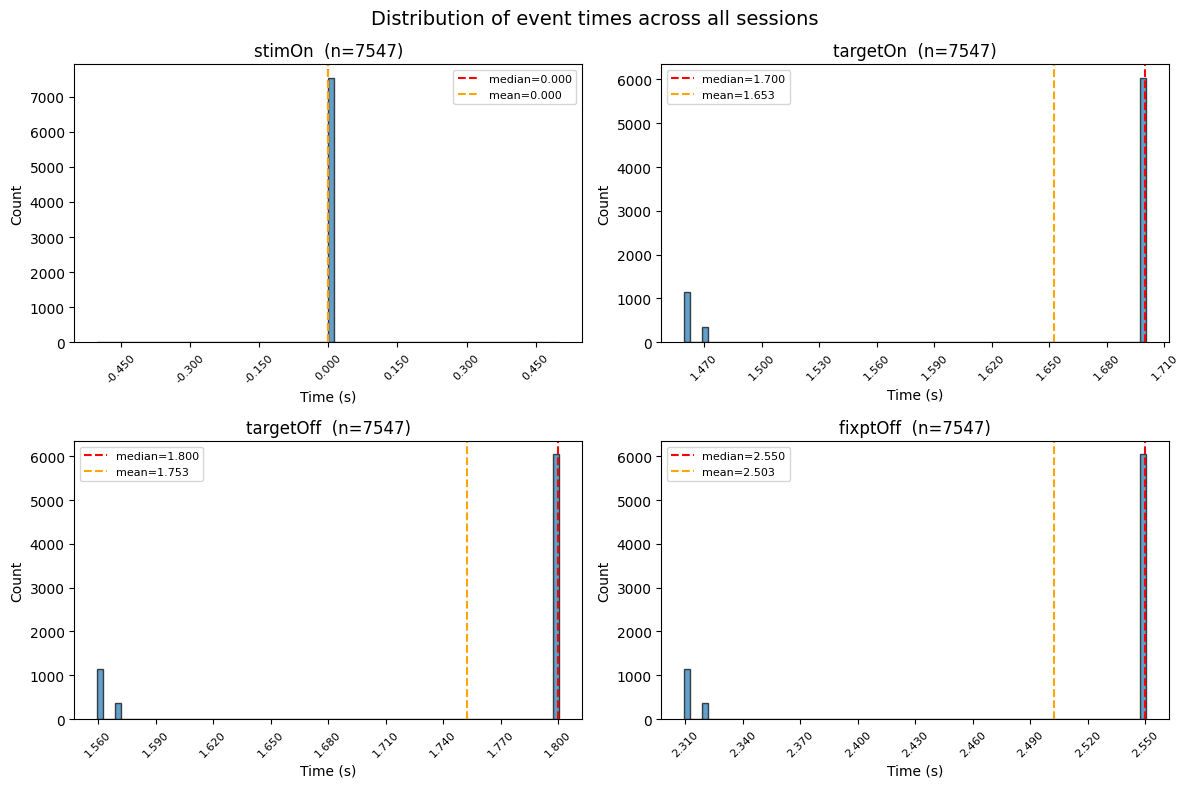

Event             Count     Mean   Median      Std      Min      Max
---------------------------------------------------------------------------
stimOn             7547    0.000    0.000    0.000    0.000    0.000
targetOn           7547    1.653    1.700    0.095    1.460    1.700
targetOff          7547    1.753    1.800    0.095    1.560    1.800
fixptOff           7547    2.503    2.550    0.095    2.310    2.550


In [ ]:
# import matplotlib.pyplot as plt

# event_cols = ['stimOn', 'targetOn', 'targetOff', 'fixptOff']

# # Collect event times across all sessions
# event_values = {col: [] for col in event_cols}

# for sess in range(len(data['trial'])):
#     df = data['trial'][sess]
#     for col in event_cols:
#         if col in df.columns:
#             vals = pd.to_numeric(df[col], errors='coerce').dropna().values
#             event_values[col].append(vals)

# # Concatenate across sessions
# for col in event_cols:
#     event_values[col] = np.concatenate(event_values[col]) if event_values[col] else np.array([])

# # Plot distributions
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.ravel()

# for i, col in enumerate(event_cols):
#     ax = axes[i]
#     vals = event_values[col]
#     if len(vals) == 0:
#         ax.set_title(f"{col} — not found")
#         continue
#     ax.hist(vals, bins=80, edgecolor='black', alpha=0.7)
#     ax.set_title(f"{col}  (n={len(vals)})")
#     ax.set_xlabel("Time (s)")
#     ax.set_ylabel("Count")
#     ax.axvline(np.median(vals), color='red', linestyle='--', label=f"median={np.median(vals):.3f}")
#     ax.axvline(np.mean(vals), color='orange', linestyle='--', label=f"mean={np.mean(vals):.3f}")
#     ax.legend(fontsize=8)

#     # More precise xticks
#     from matplotlib.ticker import MaxNLocator, FormatStrFormatter
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
#     ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
#     ax.tick_params(axis='x', rotation=45, labelsize=8)

# fig.suptitle("Distribution of event times across all sessions", fontsize=14)
# plt.tight_layout()
# plt.show()

# # Print summary stats
# print(f"{'Event':<15} {'Count':>7} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
# print("-" * 75)
# for col in event_cols:
#     vals = event_values[col]
#     if len(vals) > 0:
#         print(f"{col:<15} {len(vals):>7} {np.mean(vals):>8.3f} {np.median(vals):>8.3f} "
#               f"{np.std(vals):>8.3f} {np.min(vals):>8.3f} {np.max(vals):>8.3f}")
#     else:
#         print(f"{col:<15}     N/A")

In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.ndimage import shift as ndshift

# TARGET_ON_ALIGNED = 1.7  # desired targetOn time
# bin_size = 0.1
# time_axis = np.arange(-2.5, 3.5, bin_size)  # 60 bins

# # Event columns to shift (add/remove as needed)
# event_cols = ['stimOn', 'targetOn', 'targetOff', 'fixptOff', 
#               'responseDone', 'responseTime', 'fixptOn', 'trialRefTimes']

# for sess in range(len(data['trial'])):
#     df = data['trial'][sess]
    
#     # Get the session's targetOn (median across trials)
#     target_on_vals = pd.to_numeric(df['targetOn'], errors='coerce').dropna()
#     if len(target_on_vals) == 0:
#         print(f"Session {sess}: no valid targetOn values, skipping.")
#         continue
    
#     current_target_on = np.median(target_on_vals)
#     time_shift = TARGET_ON_ALIGNED - current_target_on  # in seconds
#     bin_shift = round(time_shift / bin_size)             # in bins (integer)
    
#     # --- Shift event times in trial DataFrame ---
#     for col in event_cols:
#         if col in df.columns:
#             df[col] = pd.to_numeric(df[col], errors='coerce') + time_shift
    
#     data['trial'][sess] = df
    
#     # --- Shift spikecounts along time axis (axis=-1) ---
#     sc = data['spikecounts'][sess]  # shape: (trials, units, timebins)
#     if bin_shift != 0:
#         # Roll along the last axis; fill rolled-in bins with 0
#         sc_shifted = np.roll(sc, bin_shift, axis=-1)
#         if bin_shift > 0:
#             sc_shifted[..., :bin_shift] = 0      # zero-pad the left
#         else:
#             sc_shifted[..., bin_shift:] = 0      # zero-pad the right
#         data['spikecounts'][sess] = sc_shifted
    
#     print(f"Session {sess}: targetOn {current_target_on:.3f} → {TARGET_ON_ALIGNED:.3f} "
#           f"(shift={time_shift:+.3f}s, {bin_shift:+d} bins)")

# print("\nDone. All sessions aligned to targetOn = 1.7 s.")

Session 0: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 1: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 2: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 3: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 4: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 5: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 6: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 7: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 8: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 9: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 10: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 11: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 12: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 13: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 14: targetOn 1.700 → 1.700 (shift=+0.000s, +0 bins)
Session 15: targetOn 1.460 → 1.700 (shift=+0.240s, +2 bins)
Session 16: targetOn 1.700 → 1.700 (shift=+0.000s,

In [ ]:
# # Quick check: targetOn should now be ~1.7 for all sessions
# for sess in range(len(data['trial'])):
#     df = data['trial'][sess]
#     vals = pd.to_numeric(df['targetOn'], errors='coerce').dropna()
#     if len(vals) > 0:
#         print(f"Session {sess}: targetOn  mean={vals.mean():.4f}  std={vals.std():.4f}")

Session 0: targetOn  mean=1.7000  std=0.0000
Session 1: targetOn  mean=1.7000  std=0.0000
Session 2: targetOn  mean=1.7000  std=0.0000
Session 3: targetOn  mean=1.7000  std=0.0000
Session 4: targetOn  mean=1.7000  std=0.0000
Session 5: targetOn  mean=1.7000  std=0.0000
Session 6: targetOn  mean=1.7000  std=0.0000
Session 7: targetOn  mean=1.7000  std=0.0000
Session 8: targetOn  mean=1.7000  std=0.0000
Session 9: targetOn  mean=1.7000  std=0.0000
Session 10: targetOn  mean=1.7000  std=0.0000
Session 11: targetOn  mean=1.7000  std=0.0000
Session 12: targetOn  mean=1.7000  std=0.0000
Session 13: targetOn  mean=1.7000  std=0.0000
Session 14: targetOn  mean=1.7000  std=0.0000
Session 15: targetOn  mean=1.7000  std=0.0000
Session 16: targetOn  mean=1.7000  std=0.0000
Session 17: targetOn  mean=1.7000  std=0.0000
Session 18: targetOn  mean=1.7000  std=0.0000
Session 19: targetOn  mean=1.7000  std=0.0000
Session 20: targetOn  mean=1.7000  std=0.0000
Session 21: targetOn  mean=1.7000  std=0.000

In [ ]:
# out_path = '/home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1_noNaN_aligned.pkl'

# with open(out_path, 'wb') as f:
#     pickle.dump(data, f)

# # Verify
# with open(out_path, 'rb') as f:
#     loaded = pickle.load(f)

# print(f"Saved to: {out_path}")
# print(f"Sessions: {len(loaded['trial'])}")
# print(f"Keys: {list(loaded.keys())}")
# print(f"Example spikecounts shape (session 0): {loaded['spikecounts'][0].shape}")

Saved to: /home/aarghavan/aslan/delsac-neural-decoding/delsac_all_bin_0.1_noNaN_aligned.pkl
Sessions: 66
Keys: ['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron']
Example spikecounts shape (session 0): (141, 104, 59)
